In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import gaussian_kde

In [3]:
df = pd.read_csv('grocerydb_cleaned.csv')
df.head()

,name,store,category,brand,FPro,FPro_class,price,price percal,package_weight,Protein,Total Fat,Carbohydrate,"Sugars, total","Fiber, total dietary",Sodium,Cholesterol
0,Stonyfield Organic Whole Milk Strawberry Beet ...,Target,baby-food,Stonyfield,0.815250,3.0,5.29,0.043984,396.8930,5.050505,3.030303,12.121212,9.090909,0.000000,0.080808,0.010101
1,Stonyfield Organic Whole Milk Pear Spinach Man...,Target,baby-food,Stonyfield,0.815250,3.0,5.29,0.043984,396.8930,5.050505,3.030303,12.121212,9.090909,0.000000,0.080808,0.010101
2,Once Upon a Farm Organic Mama Blueberry Fruit ...,Target,baby-food,Once Upon a Farm,0.583219,3.0,2.79,0.055973,90.7184,1.098901,0.549451,13.186813,7.692308,2.197802,0.010989,0.000000
3,Once Upon a Farm Organic Strawberry Kids' Dair...,Target,baby-food,Once Upon a Farm,0.451056,0.0,2.49,0.019213,90.7184,5.494505,7.692308,15.384615,8.791209,3.296703,0.000000,0.000000
4,Horizon Organic Growing Years Strawberry Kids'...,Target,baby-food,DANNON,0.773519,3.0,4.99,0.017781,396.8930,3.030303,1.010101,14.141414,6.060606,2.020202,0.050505,0.005051


<Axes: xlabel='store'>

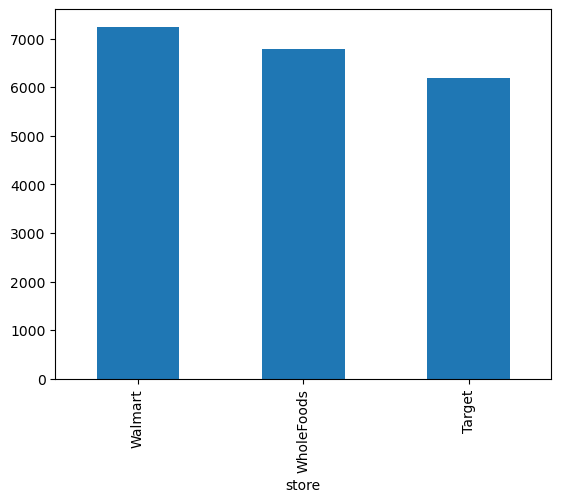

In [6]:
df['store'].value_counts().plot(kind='bar')

In [8]:
df['category'].value_counts()

category
prepared-meals-dishes      1606
pastry-chocolate-candy     1289
snacks-bars                1020
cookies-biscuit             951
produce-packaged            933
snacks-mixes-crackers       932
snacks-chips                848
cheese                      779
produce-beans-wf            770
meat-packaged               728
dairy-yogurt-drink          675
cereal                      640
ice-cream-dessert           635
bread                       530
sauce-all                   512
rolls-buns-wraps            509
soup-stew                   498
dressings                   428
sausage-bacon               390
pizza                       336
baking                      321
seafood                     320
cakes                       314
snacks-nuts-seeds           291
drink-juice                 284
snacks-dips-salsa           282
breakfast                   246
milk-milk-substitute        238
spread-squeeze              233
muffins-bagels              195
drink-shakes-other          187

In [13]:
baby_food = df[df['category']=='baby-food']
baby_food['FPro'].mean()

0.5223755053043477

In [14]:
#how processed is baby food? 
px.histogram(baby_food, x='FPro', nbins=20, title='Distribution of FPro in Baby Food')

# Visualization 1

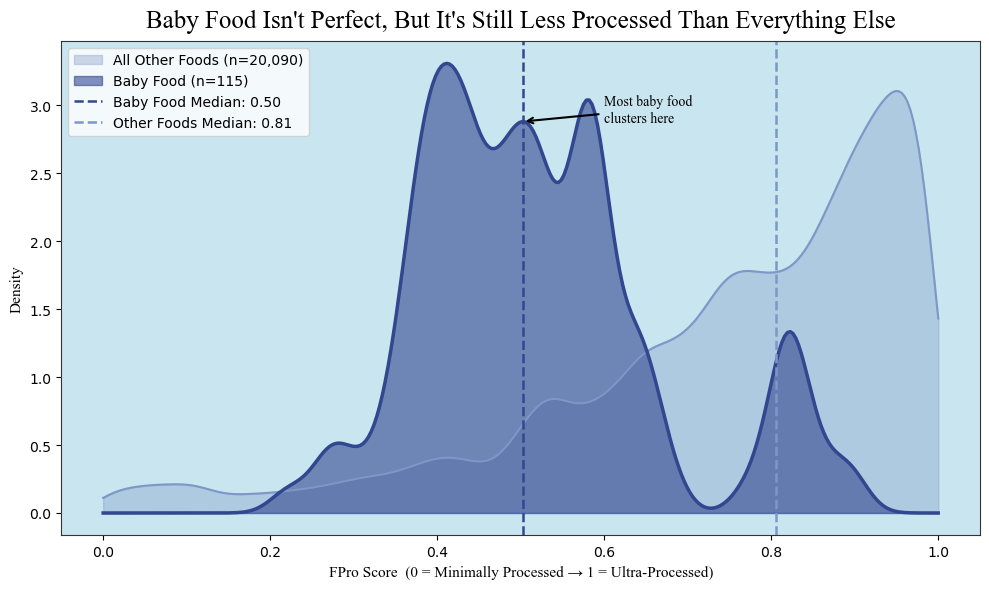

In [81]:
baby_food_processed = baby_food['FPro']
other = df[df['category']!='baby-food']
other_processed = other['FPro']

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor("#C9E6F0")

x = np.linspace(0, 1, 300)

kde_other = gaussian_kde(other_processed, bw_method=0.1)
kde_baby  = gaussian_kde(baby_food_processed,  bw_method=0.15)

ax.fill_between(x, kde_other(x), alpha=0.35, color="#7D97C7", label=f"All Other Foods (n={len(other_processed):,})")
ax.plot(x, kde_other(x), color="#7D97C7", linewidth=1.5)
 
ax.fill_between(x, kde_baby(x), alpha=0.6, color="#32478F", label=f"Baby Food (n={len(baby_food_processed)})")
ax.plot(x, kde_baby(x), color="#32478F", linewidth=2.5)

# Median lines
ax.axvline(baby_food_processed.median(),  color="#32478F", linestyle="--", linewidth=1.8,
           label=f"Baby Food Median: {baby_food_processed.median():.2f}")
ax.axvline(other_processed.median(), color="#7D97C7", linestyle="--", linewidth=1.8,
           label=f"Other Foods Median: {other_processed.median():.2f}")


# Labels
ax.set_title("Baby Food Isn't Perfect, But It's Still Less Processed Than Everything Else",
             color="Black", fontsize=18, fontweight="medium", pad=10, fontname = "Times New Roman")
ax.set_xlabel("FPro Score  (0 = Minimally Processed → 1 = Ultra-Processed)",
              color="#000000", fontsize=11, fontname = "Times New Roman")
ax.set_ylabel("Density", color="#000000", fontsize=11, fontname = "Times New Roman")
ax.tick_params(colors="#000000")
for spine in ax.spines.values():
    spine.set_color("#333333")

ax.legend(facecolor="white", labelcolor="black", fontsize=10, framealpha=0.8)

# Annotation
ax.annotate("Most baby food\nclusters here",
            xy=(baby_food_processed.median(), kde_baby(baby_food_processed.median())[0]),
            xytext=(0.60, kde_baby(baby_food_processed.median())[0]),
            color="#000000", fontsize=10, fontname = "Times New Roman",
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
 
plt.tight_layout()


# Visualization 2

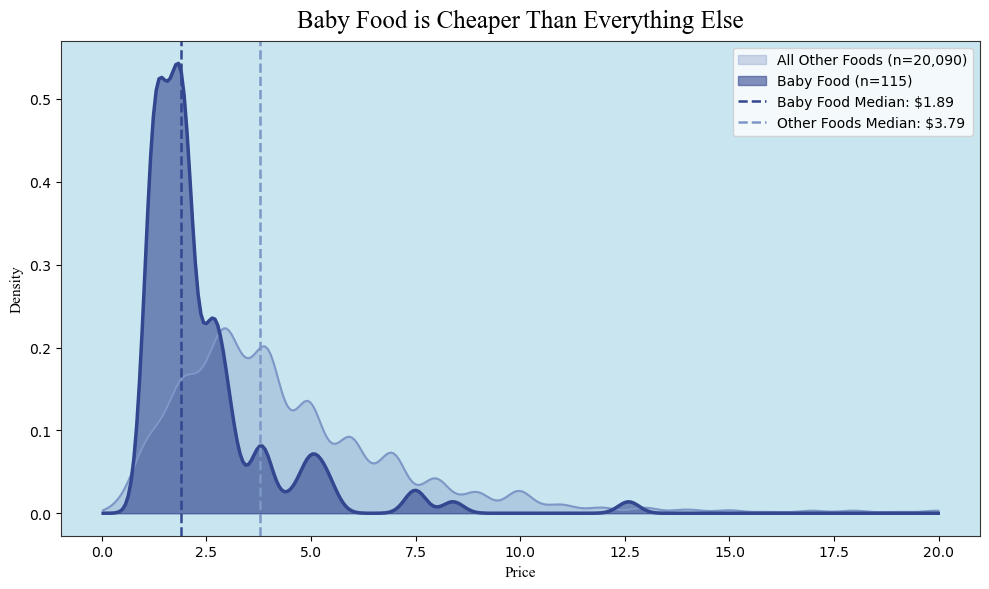

In [95]:
baby_food_price = baby_food['price']
other_price = other['price']

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor("#C9E6F0")

x = np.linspace(
    min(baby_food_price.min(), other_price.min()),
    max(baby_food_price.max(), other_price.max()),
    300
)

kde_other_price = gaussian_kde(other_price, bw_method=0.1)
kde_baby_price  = gaussian_kde(baby_food_price,  bw_method=0.15)

ax.fill_between(x, kde_other_price(x), alpha=0.35, color="#7D97C7", label=f"All Other Foods (n={len(other_price):,})")
ax.plot(x, kde_other_price(x), color="#7D97C7", linewidth=1.5)
 
ax.fill_between(x, kde_baby_price(x), alpha=0.6, color="#32478F", label=f"Baby Food (n={len(baby_food_price):,})")
ax.plot(x, kde_baby_price(x), color="#32478F", linewidth=2.5)

# Median lines
ax.axvline(baby_food_price.median(),  color="#32478F", linestyle="--", linewidth=1.8,
           label=f"Baby Food Median: ${baby_food_price.median():.2f}")
ax.axvline(other_price.median(), color="#7D97C7", linestyle="--", linewidth=1.8,
           label=f"Other Foods Median: ${other_price.median():.2f}")


# Labels
ax.set_title("Baby Food is Cheaper Than Everything Else",
             color="Black", fontsize=18, fontweight="medium", pad=10, fontname = "Times New Roman")
ax.set_xlabel("Price",
              color="#000000", fontsize=11, fontname = "Times New Roman")
ax.set_ylabel("Density", color="#000000", fontsize=11, fontname = "Times New Roman")
ax.tick_params(colors="#000000")
for spine in ax.spines.values():
    spine.set_color("#333333")

ax.legend(facecolor="white", labelcolor="black", fontsize=10, framealpha=0.8)

 
plt.tight_layout()

# Visualization 3

In [97]:
caffiene = df[df['category'] == 'drink-coffee']
caffiene

,name,store,category,brand,FPro,FPro_class,price,price percal,package_weight,Protein,Total Fat,Carbohydrate,"Sugars, total","Fiber, total dietary",Sodium,Cholesterol
5140,International Delight French Vanilla Singles C...,Target,drink-coffee,International Delight,0.797250,3.0,2.69,0.011748,297.66975,0.000000,11.538462,38.461538,38.461538,0.000000,0.000000,0.000000
5141,Land O' Lakes Mini Moo's Half & Half Coffee Cr...,Target,drink-coffee,International Delight,0.612181,1.0,2.69,0.011055,219.00000,0.000000,11.111111,0.000000,0.000000,0.000000,0.055556,0.000000
5142,International Delight Caramel Macchiato Iced C...,Target,drink-coffee,International Delight,0.826833,3.0,3.79,0.003948,1920.00000,1.388889,0.972222,8.888889,8.055556,0.000000,0.033333,0.002778
5143,International Delight Mocha Iced Coffee - 64 f...,Target,drink-coffee,International Delight,0.838435,3.0,3.79,0.003948,1920.00000,1.388889,0.972222,8.888889,8.055556,0.000000,0.033333,0.002778
5144,Califia Farms XX Espresso Cold Brew Coffee - 4...,Target,drink-coffee,Califia Farms,0.684122,3.0,5.59,0.037267,1440.00000,0.833333,1.250000,5.000000,4.166667,0.416667,0.083333,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5270,"Starbucks Vanilla Latte Iced Espresso, 14 fl oz",Walmart,drink-coffee,Starbucks,0.821648,3.0,2.68,0.012008,420.00000,1.932367,1.086957,8.695652,8.212560,0.000000,0.026570,0.003623
5271,Starbucks Frappuccino Toasted White Chocolate ...,Walmart,drink-coffee,Starbucks,0.891417,3.0,2.68,0.009106,411.00000,2.222222,1.111111,12.839506,10.864198,0.000000,0.056790,0.004938
5272,RISE Brewing Co. Oat Milk Mocha Nitro Cold Bre...,Walmart,drink-coffee,Rise Brewing Co.,0.748866,3.0,2.88,0.019200,210.00000,0.476190,2.380952,11.904762,1.428571,0.476190,0.090476,0.000000
5273,Starbucks Frappuccino Mocha Almond Milk Chille...,Walmart,drink-coffee,Starbucks,0.671648,3.0,2.68,0.015535,411.00000,0.493827,1.234568,7.407407,6.172840,0.740741,0.029630,0.000000


Text(0.5, 1.0, 'Is it Coffee or is it Sugar?')

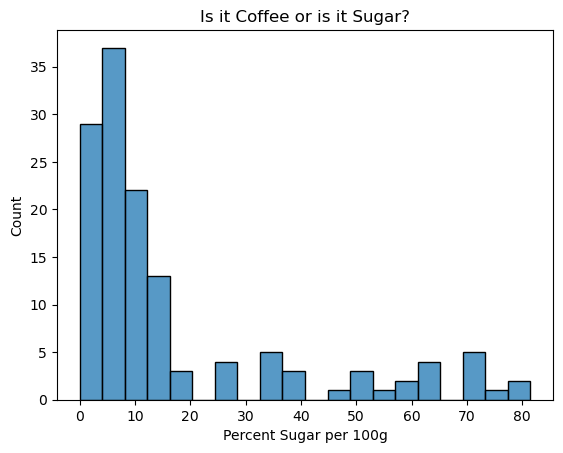

In [100]:
sns.histplot(caffiene['Carbohydrate'], bins=20)
plt.xlabel("Percent Sugar per 100g")
plt.title("Is it Coffee or is it Sugar?")

In [145]:
sugar_vs_weight =caffiene[['Carbohydrate', 'package_weight']]
px.scatter(sugar_vs_weight, x='package_weight', y='Carbohydrate')

# Visualization 4

Text(0.5, 1.0, 'Exactly how much salt is in your bacon?')

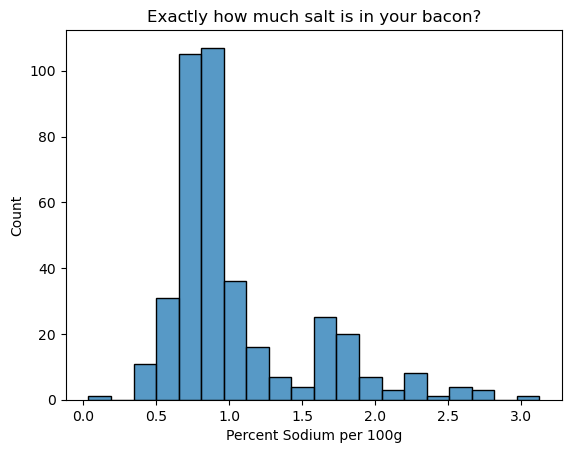

In [104]:
bacon = df[df['category'] == 'sausage-bacon']
sns.histplot(bacon['Sodium'], bins=20)
plt.xlabel("Percent Sodium per 100g")
plt.title("Exactly how much salt is in your bacon?")

# Visualization 5

Text(0.5, 1.0, 'Is Your Breakfast Real?')

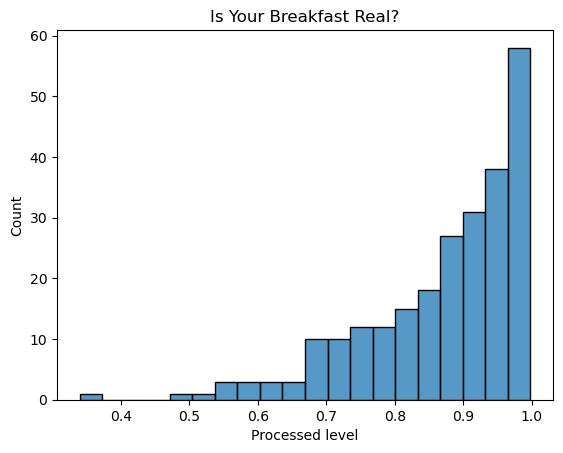

In [107]:
breakfast = df[df['category'] == 'breakfast']
sns.histplot(breakfast['FPro'], bins=20)
plt.xlabel("Processed level")
plt.title("Is Your Breakfast Real?")

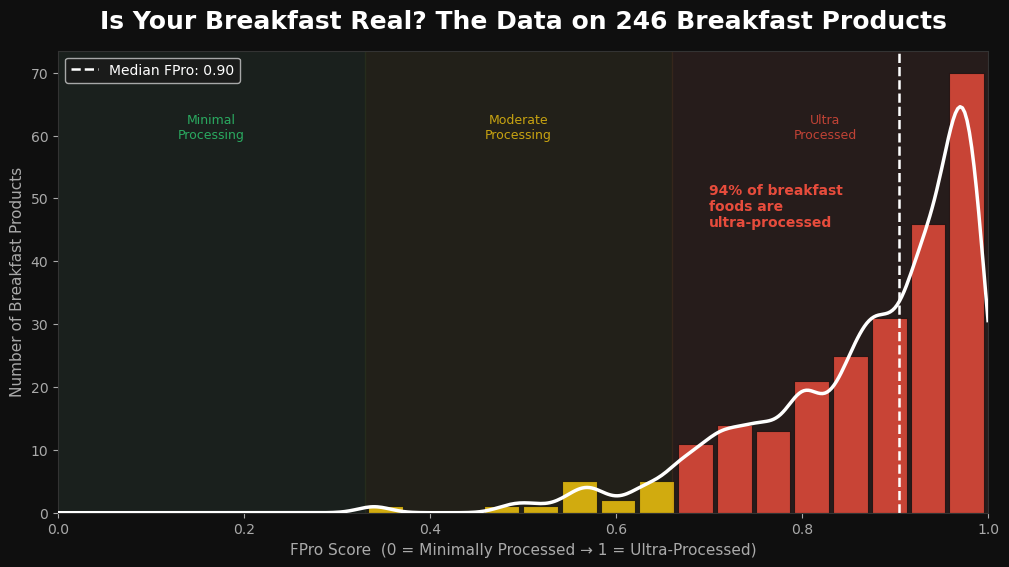

In [138]:
BG_DARK = "#0f0f0f"
BG_AX = "#1a1a1a"

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG_DARK)
ax.set_facecolor(BG_AX)

bins = np.linspace(0, 1, 25)
counts, edges = np.histogram(breakfast['FPro'], bins=bins)

zone_colors = []
for left, right in zip(edges[:-1], edges[1:]):
    mid = (left + right) / 2
    if mid < 0.33:
        zone_colors.append("#2ecc71")  # Minimally processed
    elif mid < 0.66:
        zone_colors.append("#f1c40f")  # Moderately processed
    else:
        zone_colors.append("#e74c3c")  # Ultra-processed

for left, right, count, color in zip(edges[:-1], edges[1:], counts, zone_colors):
    ax.bar(left, count, width=(right - left) * 0.9, color=color,
           alpha=0.85, align="edge", edgecolor=BG_DARK, linewidth=0.8)
    
#KDE OVERLAY 
x = np.linspace(0, 1, 400)
kde = gaussian_kde(breakfast['FPro'], bw_method=0.15)
kde_scaled = kde(x) * len(breakfast['FPro']) * (bins[1] - bins[0])  # scale to match bar heights
ax.plot(x, kde_scaled, color="white", linewidth=2.5, zorder=5)

#MEDIAN LINE
med = breakfast['FPro'].median()
ax.axvline(med, color="white", linestyle="--", linewidth=1.8,
           label=f"Median FPro: {med:.2f}")
 

# ── ZONE BACKGROUND SHADING ───────────────────────────────────────────────────
ax.axvspan(0,    0.33, alpha=0.04, color="#2ecc71")
ax.axvspan(0.33, 0.66, alpha=0.04, color="#f1c40f")
ax.axvspan(0.66, 1.0,  alpha=0.06, color="#e74c3c")
 
ax.text(0.165, counts.max() * 0.85, "Minimal\nProcessing",
        color="#2ecc71", fontsize=9, ha="center", alpha=0.8)
ax.text(0.495, counts.max() * 0.85, "Moderate\nProcessing",
        color="#f1c40f", fontsize=9, ha="center", alpha=0.8)
ax.text(0.825, counts.max() * 0.85, "Ultra\nProcessed",
        color="#e74c3c", fontsize=9, ha="center", alpha=0.8)

# ── CALLOUT ANNOTATION ────────────────────────────────────────────────────────
pct_ultra = int((breakfast['FPro'] > 0.66).sum() / len(breakfast) * 100)
ax.annotate(f"{pct_ultra}% of breakfast\nfoods are \nultra-processed",
            xy=(1.0, counts.max() * 0.55),
            xytext=(0.7, counts.max() * 0.65),
            color="#e74c3c", fontsize=10, fontweight="bold")

ax.set_title("Is Your Breakfast Real? The Data on 246 Breakfast Products", color="white", fontsize=18,
             fontweight="bold", pad=16)
ax.set_xlabel("FPro Score  (0 = Minimally Processed → 1 = Ultra-Processed)",
              color="#aaaaaa", fontsize=11)
ax.set_ylabel("Number of Breakfast Products", color="#aaaaaa", fontsize=11)
ax.set_xlim(0, 1)
ax.tick_params(colors="#aaaaaa")
for spine in ax.spines.values():
    spine.set_color("#333333")
ax.legend(facecolor=BG_AX, labelcolor="white", fontsize=10, framealpha=0.8)

In [149]:
meals = df[df['category']=='prepared-meals-dishes']
px.histogram(meals, x = 'Fiber, total dietary', nbins=20, title='Fiber Content in Prepared Meals')

(array([  2.,   3.,   5.,   4.,   8.,  16.,   7.,   5.,  14.,  18.,  32.,
         70., 140., 232., 299., 275., 202., 161.,  74.,  39.]),
 array([0.14288426, 0.18557338, 0.2282625 , 0.27095162, 0.31364074,
        0.35632986, 0.39901898, 0.4417081 , 0.48439722, 0.52708634,
        0.56977546, 0.61246458, 0.6551537 , 0.69784282, 0.74053194,
        0.78322106, 0.82591019, 0.86859931, 0.91128843, 0.95397755,
        0.99666667]),
 <BarContainer object of 20 artists>)

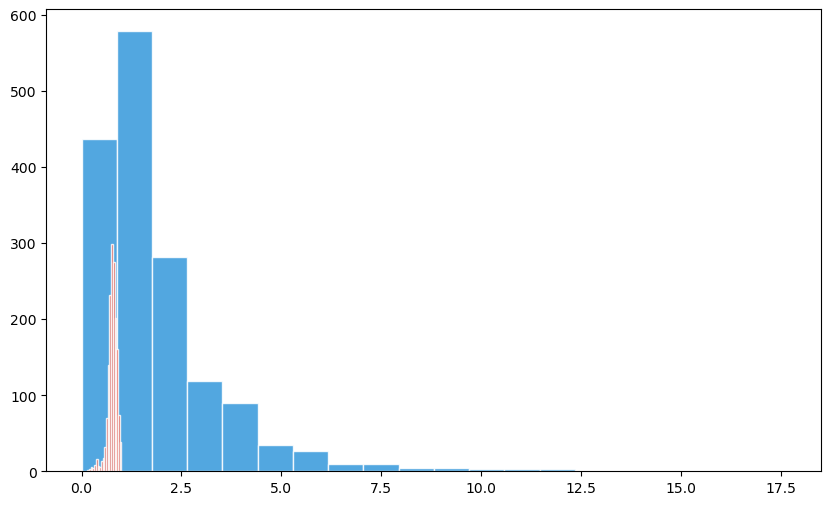

In [150]:
plt.figure(figsize=(10, 6))

plt.hist(meals['Fiber, total dietary'], bins=20, color="#3498db", edgecolor="white", alpha=0.85)
plt.hist(meals['FPro'], bins=20, color="#e74c3c", edgecolor="white", alpha=0.85)



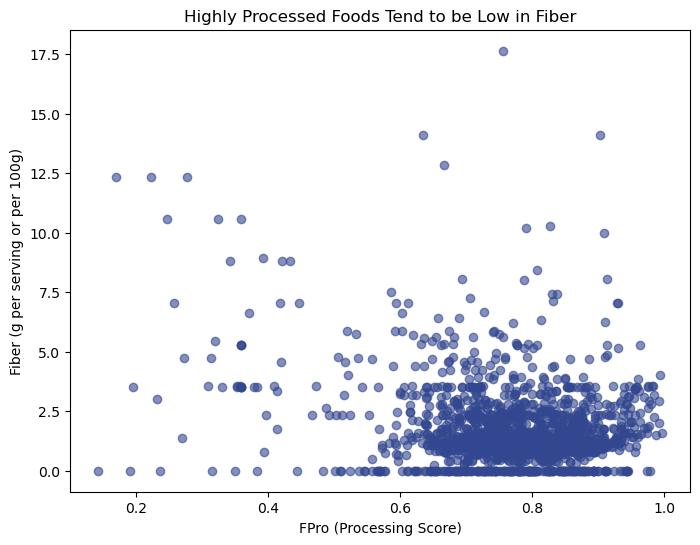

In [152]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(meals['FPro'], meals['Fiber, total dietary'], alpha=0.6, color="#32478F")

ax.set_xlabel("FPro (Processing Score)")
ax.set_ylabel("Fiber (g per serving or per 100g)")
ax.set_title("Highly Processed Foods Tend to be Low in Fiber")

plt.show()

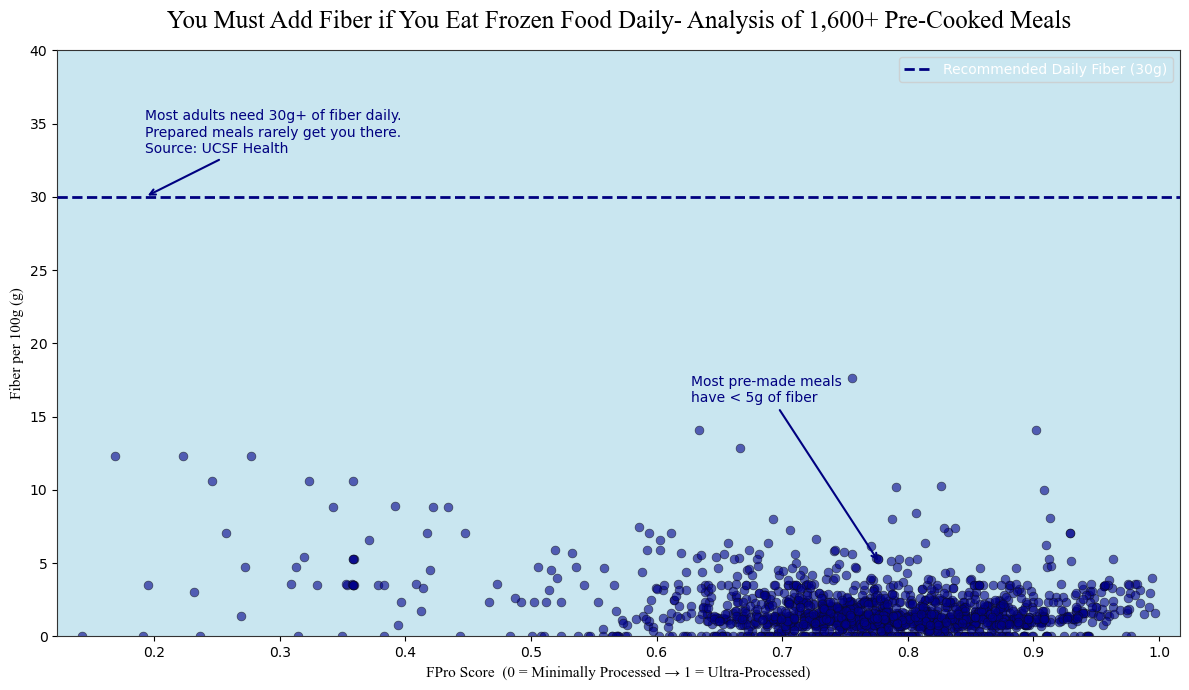

In [184]:
BG_DARK = "white"
BG_AX   = "#C9E6F0"
 
fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG_DARK)
ax.set_facecolor(BG_AX)
 
# ── SCATTER PLOT ──────────────────────────────────────────────────────────────
scatter = ax.scatter(
    meals["FPro"],
    meals["Fiber, total dietary"],
    color="darkblue",
    alpha=0.6,
    s=40,
    edgecolors="#0f0f0f",
    linewidth=0.5
)
 
# ── RECOMMENDED FIBER LINE ────────────────────────────────────────────────────
ax.axhline(30, color="navy", linestyle="--", linewidth=2, zorder=5,
           label="Recommended Daily Fiber (30g)")
 
ax.annotate("Most adults need 30g+ of fiber daily.\nPrepared meals rarely get you there.\nSource: UCSF Health",
            xy=(meals["FPro"].min() + 0.05, 30),
            xytext=(meals["FPro"].min() + 0.05, 33),
            color="navy", fontsize=10,
            arrowprops=dict(arrowstyle="->", color="navy", lw=1.5))


ax.annotate("Most pre-made meals\nhave < 5g of fiber",
            xy=(meals["FPro"].median(), 5),
            xytext=(meals["FPro"].median() - 0.15, 16),
            color="navy", fontsize=10, fontweight="medium",
            arrowprops=dict(arrowstyle="->", color="navy", lw=1.5))


# ── LABELS & STYLING ──────────────────────────────────────────────────────────
ax.set_title("You Must Add Fiber if You Eat Frozen Food Daily- Analysis of 1,600+ Pre-Cooked Meals",
             color="black", fontsize=18, fontweight="medium", pad=16, fontname = 'Times New Roman')
ax.set_xlabel("FPro Score  (0 = Minimally Processed → 1 = Ultra-Processed)",
              color="black", fontsize=11, fontname = 'Times New Roman')
ax.set_ylabel("Fiber per 100g (g)", color="black", fontsize=11, fontname = 'Times New Roman')
 
# Extend y-axis above 30g so the recommendation line is clearly visible
ax.set_ylim(0, 40)
ax.set_xlim(meals["FPro"].min() - 0.02, meals["FPro"].max() + 0.02)
 
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_color("#333333")
ax.legend(facecolor=BG_AX, labelcolor="white", fontsize=10, framealpha=0.8)
 
plt.tight_layout()